# Classical DOA algorithms — visual comparison on a single scene

Companion notebook to `verify_array.ipynb` (array-only) and
`verify_signal.ipynb` (signal-only).  Here we take the same scene, feed
it to each of the six classical estimators in `reconunet.models.classic`
and look at what they actually produce.

### What to look at

| Section | Figure | Confirms |
| --- | --- | --- |
| §0 | parameters | reproducibility |
| §1 | ground-truth steering spectrum | sanity — peaks are where we expect |
| §2 | Beamformer vs MVDR vs MUSIC | the classical resolution hierarchy |
| §3 | ESPRIT / RootMUSIC / UnitaryESPRIT | angle-only outputs on the MUSIC plot |
| §4 | all-algo table | RMSPE and runtime for the scene |
| §5 | SNR sweep | RMSPE vs SNR, per algorithm |
| §6 | preset sweep | cost of mis-calibration |

### Angle convention (important!)

* The `SceneRenderer` emits signals under **broadside-0°** angles and
  `a_m(θ) = exp(-j·2π·m·(d/λ)·sin(θ))` (note the **−j**).
* The legacy `ArrayModel` used by the classical estimators defines its
  scan as **endfire-0°**, `a_m(ψ) = exp(+j·2π·m·(d/λ)·cos(ψ))` (note
  the **+j**).
* To reconcile the two steering sets you need
  `cos(ψ) = -sin(θ)` ⇒ **`θ_broadside = ψ_classic − 90°`**.
* Scan grid is restricted to `[0°, 180°]` so the ULA's front/back image
  does not pollute the peak picker.


## 0. Imports and shared scene

Every section of this notebook re-renders from the parameters below.
Change a value, then *Kernel ▸ Restart & Run All* to propagate.


In [22]:
import sys, os, time
_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
_SRC  = os.path.join(_ROOT, "src")
# Two path inserts: the second is needed because some legacy modules
# import `from signalgen.array_processing import ...` unqualified.
for p in (_SRC, os.path.join(_SRC, "reconunet")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import matplotlib.pyplot as plt

from reconunet.data.scene_manifest import (
    Scene, ManifestMeta, ArrayType, ModulationType,
)
from reconunet.data.scene_renderer import SceneRenderer
from reconunet.signalgen.array_processing import ArrayConfig, ArrayModel
from reconunet.models.classic import (
    Beamformer, MVDR, MUSIC, RootMUSIC, ESPRIT, UnitaryESPRIT,
)

# ---- scene parameters -------------------------------------------------
M          = 8
T          = 512
D_OVER_LAM = 0.5
K          = 3
SNR_DB     = -15.0
ANGLES_DEG = np.array([-30.0, -5.0, 25.0], dtype=np.float32)
MODULATION = ModulationType.NARROWBAND
PRESETS = {
    "none":  dict(gain=0.0, phase=0.0, coup=0.0,  pos=0.0),
    "mild":  dict(gain=0.1, phase=1.0, coup=0.02, pos=1.0),
    "harsh": dict(gain=0.5, phase=5.0, coup=0.10, pos=5.0),
}
PRESET = "none"
SEED   = 2025

K_MAX = 10
angles_full = np.full(K_MAX, np.nan, dtype=np.float32)
angles_full[:K] = ANGLES_DEG[:K]

meta = ManifestMeta(M=M, T=T, element_spacing_lambda=D_OVER_LAM)

def make_scene(*, snr=SNR_DB, preset_key=PRESET, seed=SEED, k=K, angles=angles_full):
    p = PRESETS[preset_key]
    return Scene(
        seed=int(seed), n_sources=int(k),
        angles_deg=angles.astype(np.float32),
        snr_db=float(snr),
        array_type=ArrayType.ULA,
        modulation=ModulationType(int(MODULATION)),
        gain_err_dB=float(p["gain"]),
        phase_err_deg=float(p["phase"]),
        mutual_coupling=float(p["coup"]),
        position_err_pct=float(p["pos"]),
        scene_id=0,
    )

renderer = SceneRenderer(meta)

# Build a NOMINAL (no imperfections) ArrayModel for the classic estimators;
# imperfections are baked into the RENDERED data, not into the classic's
# steering matrix.  This exactly measures the cost of mis-calibration.
array_cfg = ArrayConfig(
    array_type="linear",
    num_elements=M,
    carrier_freq=2.45e9,
    element_spacing=D_OVER_LAM,
    enable_gain_phase_errors=False,
    enable_mutual_coupling=False,
    position_error_std=0.0,
)
array = ArrayModel(array_cfg, seed=0)

# Scan grid for the classic estimators (endfire-0° convention, [0°, 180°]).
# 0.25° resolution.
SCAN_CLASSIC_DEG = np.linspace(0.0, 180.0, 721)

def classic_to_broadside(est_classic_deg: np.ndarray) -> np.ndarray:
    # theta_broadside = psi_classic - 90 deg  (see notebook header for the derivation)
    return np.asarray(est_classic_deg, dtype=np.float64) - 90.0

def broadside_to_classic(theta_b_deg: np.ndarray) -> np.ndarray:
    # inverse: psi_classic = theta_broadside + 90 deg
    return np.asarray(theta_b_deg, dtype=np.float64) + 90.0

print(f"M={M}, K={K}, preset='{PRESET}', SNR={SNR_DB} dB, angles={ANGLES_DEG.tolist()} deg")


M=8, K=3, preset='none', SNR=-15.0 dB, angles=[-30.0, -5.0, 25.0] deg


## 1. Ground-truth Bartlett beam pattern

Before running any estimator, here is what the *textbook* spectrum for
these angles should look like — the Bartlett response
`P(θ) = |aᴴ(θ) R a(θ)|` evaluated on a nominal ULA, with the true `R`
replaced by its noiseless version.

If the peaks are NOT where we expect them, the angle conversion is
wrong and every subsequent section will look broken.


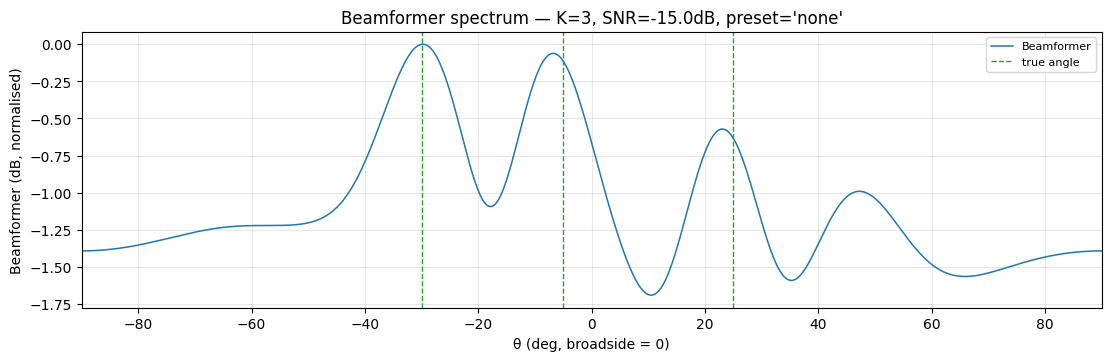

In [23]:
scene = make_scene()
res   = renderer.render(scene)
R     = res.covariance

# Classic-convention scan — we'll translate back afterwards.
est_model = Beamformer(array_model=array,
                       scan_angles_deg=SCAN_CLASSIC_DEG,
                       num_sources=K)
est_model.set_received_covariance(R)
scan_psi, spec_bf = est_model.compute_spatial_spectrum()
scan_theta_b = classic_to_broadside(scan_psi)

# Normalise to peak for plotting.
spec_bf_db = 10 * np.log10(spec_bf / spec_bf.max() + 1e-12)

fig, ax = plt.subplots(figsize=(11, 3.5), constrained_layout=True)
ax.plot(scan_theta_b, spec_bf_db, lw=1.1, label="Beamformer")
for a in ANGLES_DEG[:K]:
    ax.axvline(a, color="tab:green", ls="--", lw=1,
               label="true angle" if a == ANGLES_DEG[0] else None)
ax.set_xlim(-90, 90)
ax.set_title(f"Beamformer spectrum — K={K}, SNR={SNR_DB}dB, preset='{PRESET}'")
ax.set_xlabel("θ (deg, broadside = 0)")
ax.set_ylabel("Beamformer (dB, normalised)")
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper right")
plt.show()


## 2. Beamformer vs MVDR vs MUSIC — the classical hierarchy

Stacked on the same axes:

* **Beamformer** (Bartlett): broad main lobe, no null-steering. Peaks
  where the array has maximal coherent sum.
* **MVDR** (Capon): minimum-variance distortionless response.  Sharper
  peaks, but breaks at low SNR / correlated sources.
* **MUSIC**: orthogonality of the noise subspace — the classical tool
  of choice for well-separated, uncorrelated sources at moderate SNR.

At a well-separated, moderate-SNR, `preset='none'` scene, all three
peak on the same grid points.  The difference is the *sharpness* of the
main lobe and the height of the side lobes.


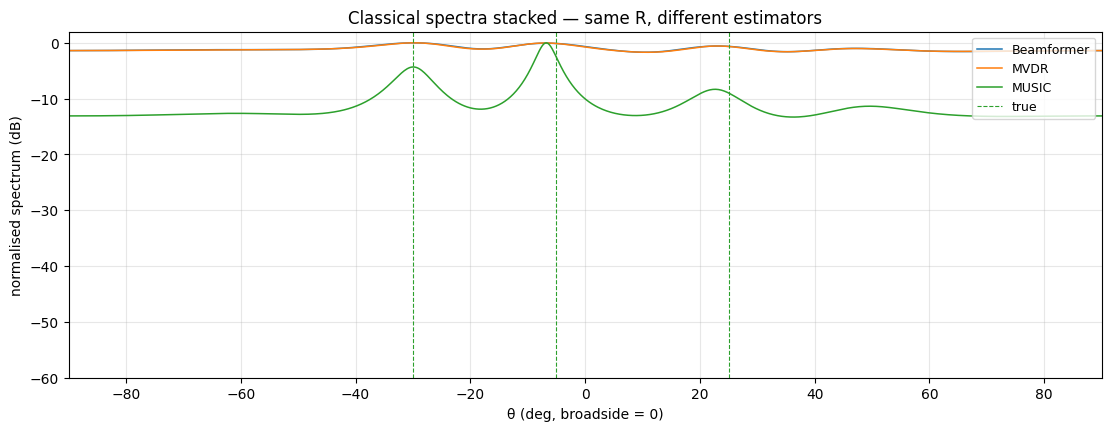

In [24]:
algos_spectra = [
    ("Beamformer", Beamformer),
    ("MVDR",       MVDR),
    ("MUSIC",      MUSIC),
]
fig, ax = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
for name, cls in algos_spectra:
    model = cls(array_model=array, scan_angles_deg=SCAN_CLASSIC_DEG, num_sources=K)
    model.set_received_covariance(R)
    _, spec = model.compute_spatial_spectrum()
    spec_db = 10 * np.log10(spec / spec.max() + 1e-12)
    ax.plot(scan_theta_b, spec_db, lw=1.1, label=name)
for a in ANGLES_DEG[:K]:
    ax.axvline(a, color="tab:green", ls="--", lw=0.8,
               label="true" if a == ANGLES_DEG[0] else None)
ax.set_xlim(-90, 90)
ax.set_ylim(-60, 2)
ax.set_title("Classical spectra stacked — same R, different estimators")
ax.set_xlabel("θ (deg, broadside = 0)")
ax.set_ylabel("normalised spectrum (dB)")
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="upper right")
plt.show()


## 3. RootMUSIC / ESPRIT / UnitaryESPRIT — angle-only outputs

These three estimators bypass the 1-D scan altogether and return a set
of angle estimates directly (from polynomial roots or subspace
rotations).  There is no spectrum to plot, so we mark their outputs on
top of the MUSIC spectrum.

If `preset='none'` and SNR is moderate, all three angle-only estimators
should sit essentially on the ground-truth markers.


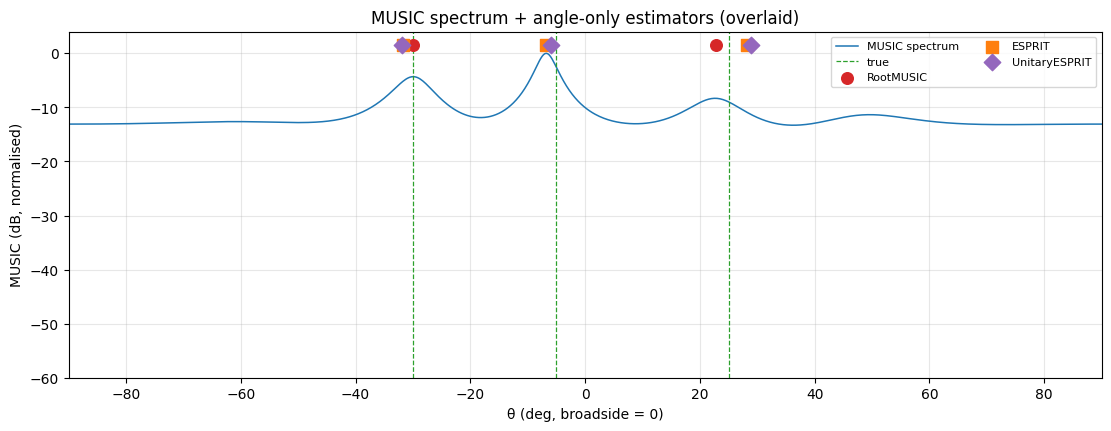

true            : [-30.0, -5.0, 25.0]
     RootMUSIC  : [-29.900348663330078, -6.786872863769531, 22.841758728027344]
        ESPRIT  : [-31.73291778564453, -6.874092102050781, 28.26093292236328]
 UnitaryESPRIT  : [-31.9333773262002, -6.014894274656129, 28.93653608793238]


In [25]:
# Re-compute MUSIC spectrum for the background.
music = MUSIC(array_model=array, scan_angles_deg=SCAN_CLASSIC_DEG, num_sources=K)
music.set_received_covariance(R)
_, music_spec = music.compute_spatial_spectrum()
music_db = 10 * np.log10(music_spec / music_spec.max() + 1e-12)

angle_only = []
for name, cls in [("RootMUSIC", RootMUSIC), ("ESPRIT", ESPRIT),
                  ("UnitaryESPRIT", UnitaryESPRIT)]:
    m = cls(array_model=array, scan_angles_deg=SCAN_CLASSIC_DEG, num_sources=K)
    m.set_received_covariance(R)
    est_psi, _ = m.estimate_doa()
    est_theta_b = np.sort(classic_to_broadside(est_psi[:K]))
    angle_only.append((name, est_theta_b))

fig, ax = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
ax.plot(scan_theta_b, music_db, lw=1.1, label="MUSIC spectrum", color="tab:blue")
for a in ANGLES_DEG[:K]:
    ax.axvline(a, color="tab:green", ls="--", lw=0.9,
               label="true" if a == ANGLES_DEG[0] else None)

markers = {"RootMUSIC": "o", "ESPRIT": "s", "UnitaryESPRIT": "D"}
colors  = {"RootMUSIC": "tab:red", "ESPRIT": "tab:orange", "UnitaryESPRIT": "tab:purple"}
for name, est in angle_only:
    for a in est:
        ax.axvline(a, color=colors[name], alpha=0.0)        # for legend colour
        ax.scatter([a], [1.5], s=70, marker=markers[name],
                   color=colors[name],
                   label=name if a == est[0] else None, zorder=3)

ax.set_xlim(-90, 90)
ax.set_ylim(-60, 4)
ax.set_title("MUSIC spectrum + angle-only estimators (overlaid)")
ax.set_xlabel("θ (deg, broadside = 0)")
ax.set_ylabel("MUSIC (dB, normalised)")
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper right", ncol=2)
plt.show()

print(f"true            : {np.sort(ANGLES_DEG[:K]).tolist()}")
for name, est in angle_only:
    print(f"{name:>14s}  : {est.tolist()}")


## 4. RMSPE + runtime table on the single scene

One number per estimator, computed permutation-invariantly on the
sorted angle vectors.  This is exactly what the full-manifest sweep
script (`run_classic_on_manifest.py`) reports, aggregated to one row.


In [26]:
def rmspe(true_deg, est_deg, K):
    t = np.sort(np.asarray(true_deg)[:K]).astype(np.float64)
    e = np.sort(np.asarray(est_deg)[:K]).astype(np.float64)
    K = min(t.size, e.size)
    return float(np.sqrt(np.mean((t[:K] - e[:K]) ** 2)))

rows = []
for name, cls in [("Beamformer", Beamformer),
                  ("MVDR",       MVDR),
                  ("MUSIC",      MUSIC),
                  ("RootMUSIC",  RootMUSIC),
                  ("ESPRIT",     ESPRIT),
                  ("UnitaryESPRIT", UnitaryESPRIT)]:
    model = cls(array_model=array, scan_angles_deg=SCAN_CLASSIC_DEG, num_sources=K)
    model.set_received_covariance(R)
    t0 = time.perf_counter()
    est_psi, _ = model.estimate_doa()
    dt = time.perf_counter() - t0
    est_theta_b = classic_to_broadside(est_psi[:K])
    rows.append((name, rmspe(ANGLES_DEG[:K], est_theta_b, K), dt * 1e3))

print(f"{'algorithm':<16} {'RMSPE (deg)':>14} {'time (ms)':>12}")
print("-" * 44)
for name, err, ms in rows:
    print(f"{name:<16} {err:>14.4f} {ms:>12.3f}")


algorithm           RMSPE (deg)    time (ms)
--------------------------------------------
Beamformer               1.5271       12.606
MVDR                     1.5903        8.412
MUSIC                    1.6989        4.877
RootMUSIC                1.6187        3.014
ESPRIT                   2.3909        2.073
UnitaryESPRIT            2.5990        3.544


## 5. SNR sweep (same angles, preset='mild')

For a fixed set of angles / K / modulation, how does each algorithm
degrade as the SNR drops?  Run a handful of trials per SNR bucket and
plot mean RMSPE.

Expectation (for `preset='mild'`, K=3, well-separated): MUSIC /
RootMUSIC / ESPRIT / UnitaryESPRIT sit close together at moderate SNR
and separate below ~0 dB; MVDR breaks early; Beamformer is always the
widest.


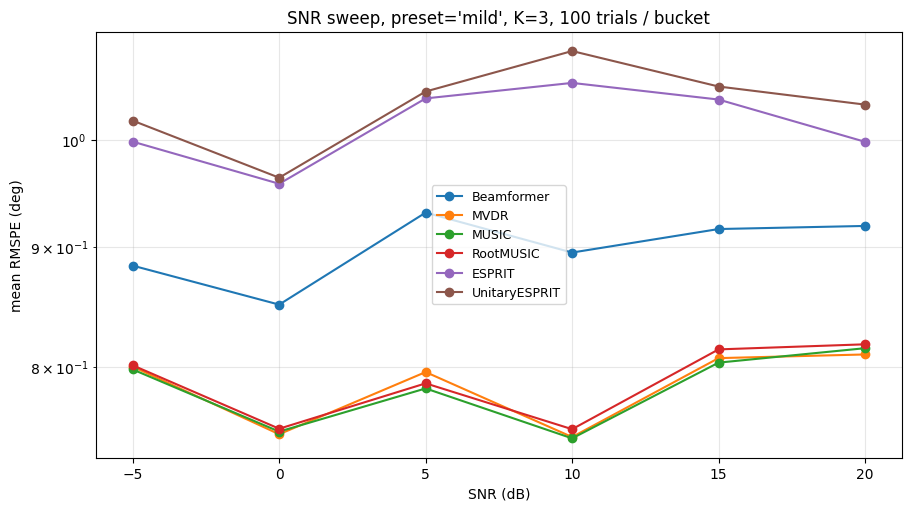

In [28]:
SNR_SWEEP_DB = np.array([-5, 0, 5, 10, 15, 20], dtype=float)
N_TRIALS    = 100

# Fix angles but sweep seed so each trial is a fresh noise realisation.
def run_one(snr, trial_seed):
    sc = make_scene(snr=snr, preset_key="harsh", seed=trial_seed)
    R_ = renderer.render(sc).covariance
    out = {}
    for name, cls in [("Beamformer", Beamformer), ("MVDR", MVDR),
                      ("MUSIC", MUSIC), ("RootMUSIC", RootMUSIC),
                      ("ESPRIT", ESPRIT), ("UnitaryESPRIT", UnitaryESPRIT)]:
        m = cls(array_model=array, scan_angles_deg=SCAN_CLASSIC_DEG, num_sources=K)
        m.set_received_covariance(R_)
        try:
            est_psi, _ = m.estimate_doa()
            est_tb = classic_to_broadside(est_psi[:K])
            out[name] = rmspe(ANGLES_DEG[:K], est_tb, K)
        except Exception:
            out[name] = np.nan
    return out

all_rows = {name: np.full((SNR_SWEEP_DB.size, N_TRIALS), np.nan)
            for name in ("Beamformer","MVDR","MUSIC","RootMUSIC","ESPRIT","UnitaryESPRIT")}
for i, snr in enumerate(SNR_SWEEP_DB):
    for j in range(N_TRIALS):
        out = run_one(float(snr), trial_seed=100 + 1000 * i + j)
        for name, err in out.items():
            all_rows[name][i, j] = err

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
for name, M_ in all_rows.items():
    ax.plot(SNR_SWEEP_DB, np.nanmean(M_, axis=1), marker="o", label=name)
ax.set_yscale("log")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("mean RMSPE (deg)")
ax.set_title(f"SNR sweep, preset='mild', K={K}, {N_TRIALS} trials / bucket")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9)
plt.show()


## 6. Preset sweep — the cost of mis-calibration

Same K, same SNR, vary only the imperfection preset.  The classical
estimators use a **nominal** steering matrix, so the perturbed
rendering is seen as model mismatch.  Harsh preset should visibly hurt
every estimator; ESPRIT variants often hold up better than scan-based
MUSIC because they exploit the shift-invariance of the sub-arrays,
which is preserved under gain/phase errors but broken by position
errors.

This is a single-scene read — add trials if you want to quantify.


In [20]:
def row_for(preset_key):
    sc   = make_scene(preset_key=preset_key, snr=35.0)
    R_   = renderer.render(sc).covariance
    out  = {}
    for name, cls in [("Beamformer", Beamformer), ("MVDR", MVDR),
                      ("MUSIC", MUSIC), ("RootMUSIC", RootMUSIC),
                      ("ESPRIT", ESPRIT), ("UnitaryESPRIT", UnitaryESPRIT)]:
        m = cls(array_model=array, scan_angles_deg=SCAN_CLASSIC_DEG, num_sources=K)
        m.set_received_covariance(R_)
        try:
            est_psi, _ = m.estimate_doa()
            est_tb = classic_to_broadside(est_psi[:K])
            out[name] = rmspe(ANGLES_DEG[:K], est_tb, K)
        except Exception:
            out[name] = np.nan
    return out

headers = ["Beamformer","MVDR","MUSIC","RootMUSIC","ESPRIT","UnitaryESPRIT"]
print(f"{'preset':<10} " + "  ".join(f"{h:>13}" for h in headers))
print("-" * 94)
for pk in ("none", "mild", "harsh"):
    r = row_for(pk)
    print(f"{pk:<10} " + "  ".join(f"{r[h]:>13.4f}" for h in headers))
print("\nRMSPE in degrees; lower is better.  The 'none' row is the floor;\n"
      "the 'harsh' row is the cost of ignoring the per-scene calibration.")


preset        Beamformer           MVDR          MUSIC      RootMUSIC         ESPRIT  UnitaryESPRIT
----------------------------------------------------------------------------------------------
none              0.3729         0.0001         0.0000         0.0010         0.0026         0.0027
mild              0.5573         0.2875         0.3042         0.3013         0.2222         0.2273
harsh             1.5217         1.3257         1.4343         1.4423         0.7386         0.7500

RMSPE in degrees; lower is better.  The 'none' row is the floor;
the 'harsh' row is the cost of ignoring the per-scene calibration.


## 7. Where to go from here

* Want to plot a **polar** version of the spectrum?  Replace the linear
  `ax.plot(scan_theta_b, spec_db)` with `ax = plt.subplot(projection="polar")`
  and `ax.plot(np.deg2rad(scan_theta_b + 90), 10 ** (spec_db / 20))`.
  (The `+90` puts broadside at the top.)
* Want to see how the ESPRIT family behaves under **correlated**
  sources (coherent multipath)?  Set `HAS_MULTIPATH=True` in
  `verify_signal.ipynb`, copy the scene params back here, and re-run §3.
* Want to batch this across many scenes?  That is exactly what
  `scripts/verify/run_classic_on_manifest.py` does — and it reports
  the same RMSPE numbers per bucket.
